In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 68.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 57.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.3 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.1
    Uninstalling cachetools-6.2.1:
      Successfully uninstalled cachetools-6.2.1


Loading dataset...
Original shape: (303, 14)
Shape after dropping NA: (297, 14)


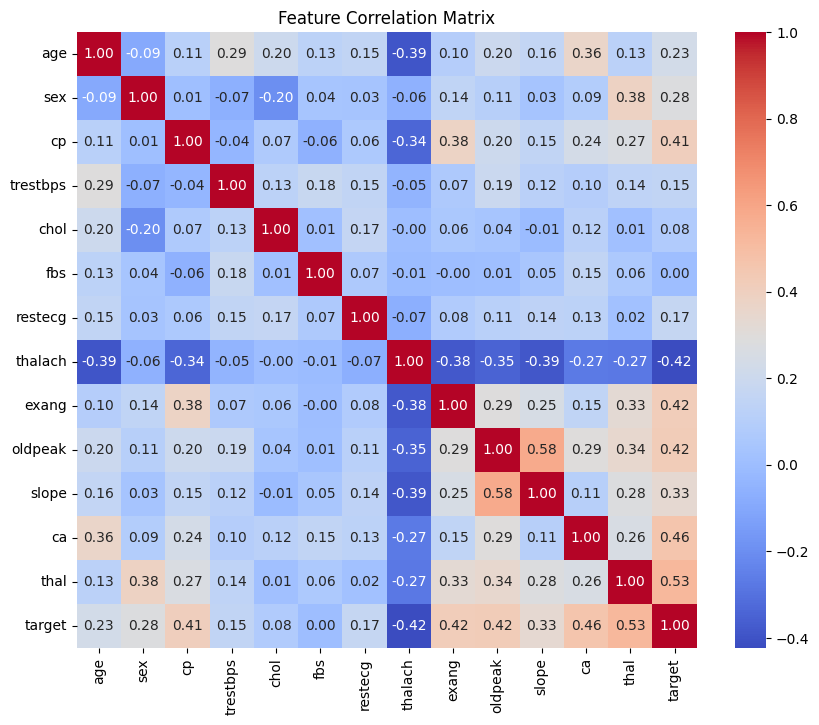

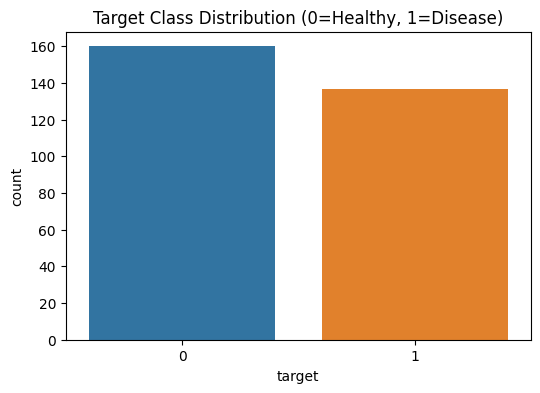

2026/01/05 17:35:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/05 17:35:12 INFO mlflow.store.db.utils: Updating database tables
2026/01/05 17:35:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/05 17:35:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/05 17:35:12 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/01/05 17:35:12 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026/01/05 17:35:12 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2026/01/05 17:35:12 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2026/01/05 17:35:12 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2026/01/05 17:35:12 INFO alembic.runtime.migration: Running 

--- Logistic_Regression ---
Accuracy: 0.8333, AUC: 0.9498


2026/01/05 17:35:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- Random_Forest ---
Accuracy: 0.8667, AUC: 0.9420
Saving Random Forest as the final model.
Final model saved to: models/heart_disease_model/model.joblib
Scaler saved to: models/heart_disease_model/scaler.joblib


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

# ==========================================
# 1. Configuration & Setup
# ==========================================
class Config:
    # URL for UCI Heart Disease Dataset (Cleveland)
    DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    COLUMN_NAMES = [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
    ]
    TEST_SIZE = 0.2
    RANDOM_STATE = 42
    MODEL_OUTPUT_DIR = "models/heart_disease_model"
    EXPERIMENT_NAME = "Heart_Disease_Prediction"

cfg = Config()
os.makedirs(cfg.MODEL_OUTPUT_DIR, exist_ok=True)

# ==========================================
# 2. Data Acquisition & Cleaning
# ==========================================
def load_data():
    print("Loading dataset...")
    df = pd.read_csv(cfg.DATA_URL, names=cfg.COLUMN_NAMES, na_values="?")
    print(f"Original shape: {df.shape}")
    
    # Handle Missing Values (Imputation)
    df = df.dropna()
    print(f"Shape after dropping NA: {df.shape}")
    
    # Binary Target: 0 = No Disease, 1-4 = Disease. Convert to 0 vs 1.
    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
    return df

df = load_data()

# ==========================================
# 3. Exploratory Data Analysis (EDA)
# ==========================================
# 
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Class Balance
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title("Target Class Distribution (0=Healthy, 1=Disease)")
plt.show()

# ==========================================
# 4. Feature Engineering
# ==========================================
X = df.drop("target", axis=1)
y = df["target"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=cfg.TEST_SIZE, random_state=cfg.RANDOM_STATE, stratify=y
)

# Scaling (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for reproducibility in the Flask App
joblib.dump(scaler, os.path.join(cfg.MODEL_OUTPUT_DIR, "scaler.joblib"))

# ==========================================
# 5. Model Development & Experiment Tracking
# ==========================================
mlflow.set_experiment(cfg.EXPERIMENT_NAME)

def train_and_evaluate(model, model_name):
    with mlflow.start_run(run_name=model_name):
        # Train
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        print(f"--- {model_name} ---")
        print(f"Accuracy: {acc:.4f}, AUC: {auc:.4f}")
        
        # Logging to MLflow
        mlflow.log_param("model_type", model_name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("auc", auc)
        
        # Save Model Artifact
        mlflow.sklearn.log_model(model, "model")
        
        return model, acc

# --- Model 1: Logistic Regression ---
lr_model = LogisticRegression(random_state=cfg.RANDOM_STATE)
trained_lr, lr_acc = train_and_evaluate(lr_model, "Logistic_Regression")

# --- Model 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=cfg.RANDOM_STATE)
trained_rf, rf_acc = train_and_evaluate(rf_model, "Random_Forest")

# ==========================================
# 6. Model Packaging (Saving Best Model)
# ==========================================
# Select best model based on Accuracy
if rf_acc > lr_acc:
    print("Saving Random Forest as the final model.")
    final_model = trained_rf
else:
    print("Saving Logistic Regression as the final model.")
    final_model = trained_lr

# Save locally for the Flask App (Simulating the 'save_pretrained' behavior)
model_path = os.path.join(cfg.MODEL_OUTPUT_DIR, "model.joblib")
joblib.dump(final_model, model_path)
print(f"Final model saved to: {model_path}")
print(f"Scaler saved to: {os.path.join(cfg.MODEL_OUTPUT_DIR, 'scaler.joblib')}")